# S&P 500 probabilistic forecasting with adaptive conformal inference

This notebook evaluates one-trading-session-ahead forecasts of S&P 500 log returns. The chronology is deliberately stricter than a single train/test split:

1. observations through 2022 fit/tune candidate point models;
2. 2023 selects the classical/tree winner and the DL winner independently by RMSE on the original log-return representation;
3. the winners are refitted through 2023 and their 2024 errors calibrate the conformal distributions;
4. the same frozen configurations are refitted through 2024 and issue rolling one-step forecasts for the untouched 2025 test period; ACI updates its interval after each observed return.

The point model is therefore selected specifically for this financial target; a winner from EMAE or the synthetic exercises is not reused. Daily log returns are already stationary and the diagnostic AutoStationary fit only introduced a negligible linear detrend, so classical, tree, and deep-learning candidates all retain the original target. This avoids fitting an economically redundant second representation.

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from thesis.dl_evaluation import DL_MODEL_NAMES
from thesis.probabilistic_evaluation import (
    DEFAULT_CLASSICAL_MODELS,
    DEFAULT_ML_MODELS,
    DEFAULT_PARAMETRIC_CLASSICAL_MODELS,
    adapt_daily_dl_configs,
    conformalize_selected_models,
    forecast_classical_stage,
    forecast_fixed_dl_stage,
    forecast_ml_stage,
    forecast_parametric_classical_stage,
    load_sp500_returns,
    plot_interval_forecast,
    save_selection_config,
    score_prediction_frames,
    split_sp500_stages,
    tune_ml_candidate,
    validate_dl_candidates,
)
from thesis.reporting import (
    dataset_descriptor,
    figure_path,
    publication_latex,
    save_matplotlib_figure,
)

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision('high')

## Controls and model scope

The neural screen uses the same complete 15-architecture set as the manual-dataset `dl_models` exercise: recurrent baselines, linear/MLP and basis-expansion models, convolutional and attention architectures, TSMixer, and KAN. NLinear remains the low-capacity linear benchmark, while RNN, LSTM, and GRU separately benchmark recurrent cells. Four Optuna trials per architecture keep the probabilistic first pass tractable while applying an equal budget to every candidate.

The parametric classical screen adds AutoETS, AutoARIMA, and AutoTheta. StatsForecast fits each specification at the first validation origin and uses its `forward` implementation at subsequent one-step origins (`refit=False`), so it sees newly observed returns without repeating the complete automatic search 250 times. AutoTBATS is excluded because its installed implementation lacks this forward interface and exact evaluation would require a full automatic refit at every daily origin. Actual rolling-stage runtimes are reported for every active model and representation. ZeroReturn is evaluated only on the original scale: a value of zero in an automatically transformed coordinate system is not the economic zero-return forecast.

In [ ]:
DATA_PATH = Path('thesis/data/sp500_daily.csv')
RESULTS_DIR = Path('thesis/results')
DL_CONFIG_DIR = Path('thesis/model_configs/dl')
SELECTION_CONFIG_PATH = Path('thesis/model_configs/sp500_probabilistic_selection.json')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SELECTION_YEAR = 2023
CALIBRATION_YEAR = 2024
TEST_YEAR = 2025
SELECTION_METRIC = 'rmse'
CLASSICAL_TRANSFORMATIONS = ['Original']
ML_TRANSFORMATIONS = ['Original']
REPRESENTATIONS = list(dict.fromkeys(
    CLASSICAL_TRANSFORMATIONS + ML_TRANSFORMATIONS
))

CLASSICAL_MODELS = list(DEFAULT_CLASSICAL_MODELS)
PARAMETRIC_CLASSICAL_MODELS = list(DEFAULT_PARAMETRIC_CLASSICAL_MODELS)
CLASSICAL_SEASON_LENGTH = 5  # one trading week
ML_MODELS = list(DEFAULT_ML_MODELS)
ML_LAGS = [1, 2, 3, 5, 10, 20, 60, 120, 252]
ML_OPTUNA_TRIALS = 25
ML_TIME_SERIES_SPLITS = 3

RUN_DL = True
RUN_SELECTION_SEARCH = False  # frozen point-model choices are reused
REFRESH_CLASSICAL_ML_TIMES = False  # True reruns only classical/ML timing and updates Table 61
RESET_DL_SELECTION = False  # True forces every Auto architecture to rerun
DL_MODELS = list(DL_MODEL_NAMES)
DL_INPUT_SIZE_CANDIDATES = [20, 60, 120, 252]
DL_INTERNAL_VAL_SIZE = 252
DL_OPTUNA_TRIALS = 4
DL_MAX_STEPS = 500

INTERVAL_LEVEL = 90
ACI_GAMMA = 0.005
PLOT_TAIL = 30
SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'

,Partition,Rows,Start,End
0,train,5786,2000-01-04,2022-12-30
1,selection,250,2023-01-03,2023-12-29
2,calibration,252,2024-01-02,2024-12-31
3,test,250,2025-01-02,2025-12-31


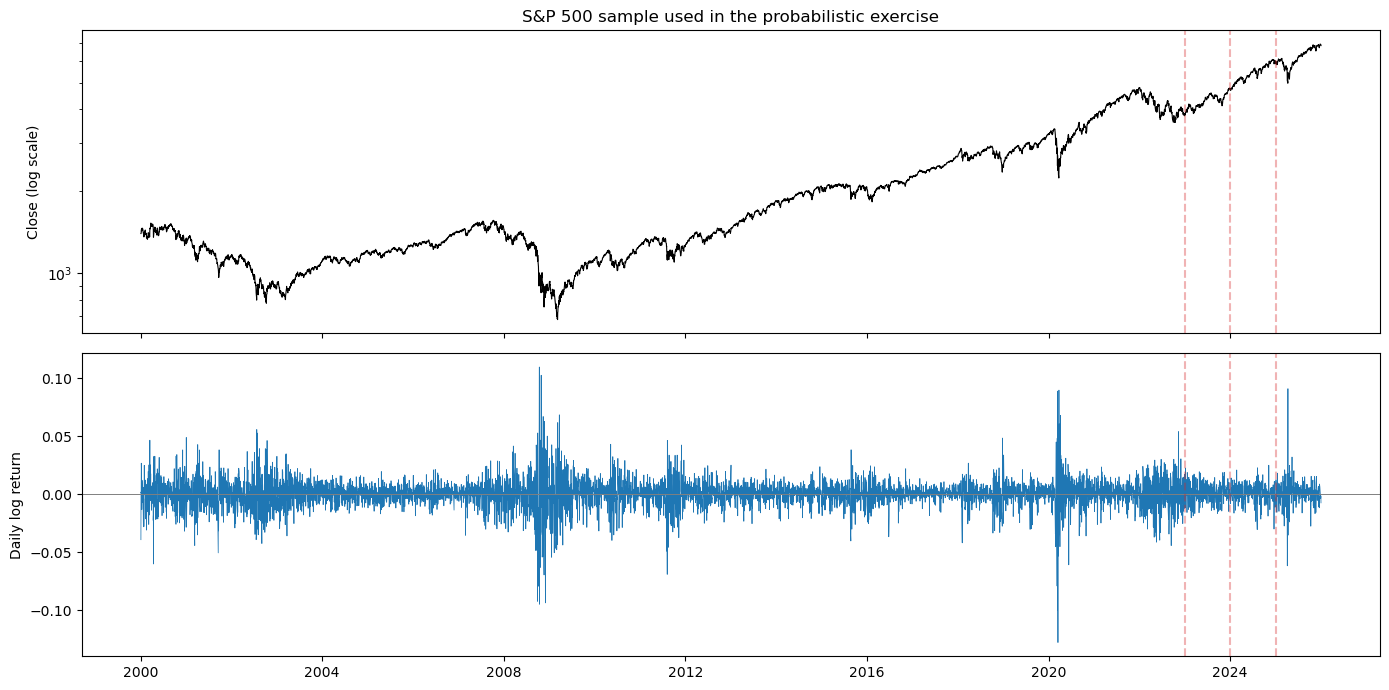

In [3]:
sp500 = load_sp500_returns(DATA_PATH)
partitions = split_sp500_stages(
    sp500,
    selection_year=SELECTION_YEAR,
    calibration_year=CALIBRATION_YEAR,
    test_year=TEST_YEAR,
)

split_audit = pd.DataFrame([
    {
        'Partition': name,
        'Rows': len(frame),
        'Start': frame['date'].min().date(),
        'End': frame['date'].max().date(),
    }
    for name, frame in partitions.items()
])
display(split_audit)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(sp500['date'], sp500['close'], color='black', linewidth=0.8)
axes[0].set_yscale('log')
axes[0].set_ylabel('Close (log scale)')
axes[0].set_title('S&P 500 sample used in the probabilistic exercise')
axes[1].plot(sp500['date'], sp500['y'], color='tab:blue', linewidth=0.55)
axes[1].axhline(0, color='grey', linewidth=0.7)
axes[1].set_ylabel('Daily log return')
for axis in axes:
    for year in (SELECTION_YEAR, CALIBRATION_YEAR, TEST_YEAR):
        axis.axvline(pd.Timestamp(f'{year}-01-01'), color='tab:red', alpha=0.35, linestyle='--')
fig.tight_layout();

## 1. External model selection on 2023

The rolling forecasts below use the actual return observed at session \(t\) only when forecasting \(t+1\). ML hyperparameters are tuned inside the pre-2023 fitting sample with ordered expanding-window `TimeSeriesSplit`; the whole 2023 block remains external model-selection data. All candidates use the original stationary log-return representation.

To fill or refresh only the classical and ML computation times in Table 61, set `REFRESH_CLASSICAL_ML_TIMES = True`, run the setup cells through the data split, and then run only the classical/ML cell and the parametric-classical cell below. The frozen metrics and selections are preserved; only their timing field is updated. Reset the flag to `False` afterwards.

In [4]:
train_df = partitions['train']
selection_df = partitions['selection']
selection_frames = []
candidate_registry = {}
ml_best_params = {}
runtime_rows = []
selection_results_path = RESULTS_DIR / 'sp500_point_model_selection_2023.csv'

def persist_selection_times(timing_rows):
    """Update only recorded selection times in the frozen metrics CSV."""
    if not timing_rows:
        return pd.read_csv(selection_results_path)
    saved = pd.read_csv(selection_results_path)
    timing = pd.DataFrame(timing_rows)
    if timing['Model'].duplicated().any():
        duplicates = timing.loc[timing['Model'].duplicated(), 'Model'].tolist()
        raise ValueError(f'Duplicate timing rows: {duplicates}')
    missing = sorted(set(timing['Model']) - set(saved['Model']))
    if missing:
        raise KeyError(f'Timed models are absent from the frozen selection CSV: {missing}')
    time_map = timing.set_index('Model')['selection_tuning_and_fit_seconds']
    selected = saved['Model'].isin(time_map.index)
    saved.loc[selected, 'selection_tuning_and_fit_seconds'] = (
        saved.loc[selected, 'Model'].map(time_map).astype(float)
    )
    saved.to_csv(selection_results_path, index=False)
    return saved

if not RUN_SELECTION_SEARCH:
    if not SELECTION_CONFIG_PATH.exists():
        raise FileNotFoundError(
            'Frozen point-model selection is unavailable; set '
            'RUN_SELECTION_SEARCH=True to create it.'
        )
    selection_payload = json.loads(
        SELECTION_CONFIG_PATH.read_text(encoding='utf-8')
    )
    if (
        int(selection_payload.get('seed', -1)) != SEED
        or selection_payload.get('selection_metric') != SELECTION_METRIC
        or int(selection_payload.get('selection_year', -1)) != SELECTION_YEAR
        or int(selection_payload.get('calibration_year', -1)) != CALIBRATION_YEAR
        or int(selection_payload.get('test_year', -1)) != TEST_YEAR
    ):
        raise ValueError('Frozen point-model selection settings do not match')
    representation_winners = selection_payload['selected_classical_ml']
    classical_ml_selection_metrics = pd.read_csv(
        selection_results_path
    )

run_classical_ml_block = RUN_SELECTION_SEARCH or REFRESH_CLASSICAL_ML_TIMES

for transformation in (
    CLASSICAL_TRANSFORMATIONS if run_classical_ml_block else []
):
    active_classical = (
        CLASSICAL_MODELS if transformation == 'Original'
        else [name for name in CLASSICAL_MODELS if name != 'ZeroReturn']
    )
    for model_name in active_classical:
        stage_start = time.perf_counter()
        frame = forecast_classical_stage(
            train_df, selection_df, model_name, transformation
        )
        stage_seconds = time.perf_counter() - stage_start
        selection_frames.append(frame)
        label = frame['Model'].iloc[0]
        candidate_registry[label] = {
            'family': 'Classical', 'model_name': model_name,
            'transformation': transformation, 'params': {},
        }
        runtime_rows.append({
            'Model': label,
            'Tuning Time': 0.0,
            'Final Fit + 2023 Rolling Forecast': stage_seconds,
            'Selection Total Time': stage_seconds,
            'selection_tuning_and_fit_seconds': stage_seconds,
        })

for transformation in (
    ML_TRANSFORMATIONS if run_classical_ml_block else []
):
    for model_name in ML_MODELS:
        print(f'Tuning {model_name} on {transformation} returns...')
        params, tuning_seconds = tune_ml_candidate(
            train_df, model_name, transformation, ML_LAGS,
            ML_OPTUNA_TRIALS, SEED, ML_TIME_SERIES_SPLITS,
        )
        frame, stage_seconds = forecast_ml_stage(
            train_df, selection_df, model_name, transformation,
            params, ML_LAGS, SEED,
        )
        selection_frames.append(frame)
        label = frame['Model'].iloc[0]
        ml_best_params[label] = params
        candidate_registry[label] = {
            'family': 'ML', 'model_name': model_name,
            'transformation': transformation, 'params': params,
        }
        runtime_rows.append({
            'Model': label, 'Tuning Time': tuning_seconds,
            'Optuna Trials': ML_OPTUNA_TRIALS,
            'Temporal Folds': ML_TIME_SERIES_SPLITS,
            'Tuning Fits': ML_OPTUNA_TRIALS * ML_TIME_SERIES_SPLITS,
            'Final Fit + 2023 Rolling Forecast': stage_seconds,
            'Selection Total Time': tuning_seconds + stage_seconds,
            'selection_tuning_and_fit_seconds': tuning_seconds + stage_seconds,
        })

if RUN_SELECTION_SEARCH:
    classical_ml_selection_metrics = score_prediction_frames(selection_frames)
    timing_map = pd.DataFrame(runtime_rows).set_index('Model')[
        'selection_tuning_and_fit_seconds'
    ]
    classical_ml_selection_metrics['selection_tuning_and_fit_seconds'] = (
        classical_ml_selection_metrics['Model'].map(timing_map)
    )
if REFRESH_CLASSICAL_ML_TIMES:
    classical_ml_selection_metrics = persist_selection_times(runtime_rows)
display(classical_ml_selection_metrics)
display(pd.DataFrame(runtime_rows))

Tuning XGBRandomForest on Original returns...


[I 2026-07-30 09:52:00,057] A new study created in memory with name: no-name-ba776ff6-210d-435f-a560-dd0666ae4398
[I 2026-07-30 09:52:00,666] Trial 0 finished with value: 0.012543754717947232 and parameters: {'n_estimators': 300, 'max_depth': 8, 'min_child_weight': 7.8048907604354145, 'subsample': 0.6992163194560455, 'colsample_bynode': 0.5769990683022781, 'reg_alpha': 2.995711795117957e-05, 'reg_lambda': 3.92416571262216e-05}. Best is trial 0 with value: 0.012543754717947232.
[I 2026-07-30 09:52:01,510] Trial 1 finished with value: 0.012694082051484722 and parameters: {'n_estimators': 500, 'max_depth': 7, 'min_child_weight': 1.150832718824721, 'subsample': 0.919589882223024, 'colsample_bynode': 0.8163412746808878, 'reg_alpha': 1.8562803846727637e-06, 'reg_lambda': 0.00022691678333356587}. Best is trial 0 with value: 0.012543754717947232.
[I 2026-07-30 09:52:01,635] Trial 2 finished with value: 0.012532385912173765 and parameters: {'n_estimators': 150, 'max_depth': 4, 'min_child_weight

Tuning LightGBM on Original returns...


[I 2026-07-30 09:52:06,308] Trial 0 finished with value: 0.012465096169205478 and parameters: {'max_depth': 6, 'n_estimators': 550, 'learning_rate': 0.06407258939839941, 'num_leaves': 24, 'min_child_samples': 10, 'subsample': 0.723825001469219, 'colsample_bytree': 0.6459174364079601, 'reg_alpha': 2.469220368184978, 'reg_lambda': 0.2538633844528103}. Best is trial 0 with value: 0.012465096169205478.
[I 2026-07-30 09:52:06,509] Trial 1 finished with value: 0.012730647486716621 and parameters: {'max_depth': 2, 'n_estimators': 550, 'learning_rate': 0.0496698152505767, 'num_leaves': 4, 'min_child_samples': 30, 'subsample': 0.6917845106754148, 'colsample_bytree': 0.6345271100166164, 'reg_alpha': 1.4219330983897993e-05, 'reg_lambda': 8.383699366707573e-05}. Best is trial 0 with value: 0.012465096169205478.
[I 2026-07-30 09:52:06,632] Trial 2 finished with value: 0.012744192832854278 and parameters: {'max_depth': 2, 'n_estimators': 300, 'learning_rate': 0.030538581253391758, 'num_leaves': 4, '

,Model,Base Model,Target Transformation,mae,mse,rmse,selection_tuning_and_fit_seconds,Status,Error
0,LightGBM,LightGBM,Original,0.006462,0.000068,0.008251,6.112637,NaN,NaN
1,AutoLSTM,AutoLSTM,Original,0.006455,0.000068,0.008253,46.466838,Completed,NaN
2,XGBRandomForest,XGBRandomForest,Original,0.006461,0.000068,0.008253,5.971172,NaN,NaN
3,HistoricAverage,HistoricAverage,Original,0.006454,0.000068,0.008254,0.058820,NaN,NaN
4,AutoETS,AutoETS,Original,0.006466,0.000068,0.008260,NaN,NaN,NaN
5,ZeroReturn,ZeroReturn,Original,0.006469,0.000068,0.008270,0.007467,NaN,NaN
6,AutoGRU,AutoGRU,Original,0.006481,0.000068,0.008271,44.940951,Completed,NaN
7,AutoVanillaTransformer,AutoVanillaTransformer,Original,0.006461,0.000069,0.008279,109.826679,Completed,NaN
8,AutoTiDE,AutoTiDE,Original,0.006653,0.000069,0.008314,59.555366,Completed,NaN
9,AutoARIMA,AutoARIMA,Original,0.006556,0.000069,0.008324,NaN,NaN,NaN


,Model,Tuning Time,Final Fit + 2023 Rolling Forecast,Selection Total Time,selection_tuning_and_fit_seconds,Optuna Trials,Temporal Folds,Tuning Fits
0,ZeroReturn,0.000000,0.007467,0.007467,0.007467,NaN,NaN,NaN
1,HistoricAverage,0.000000,0.058820,0.058820,0.058820,NaN,NaN,NaN
2,Naive,0.000000,0.002722,0.002722,0.002722,NaN,NaN,NaN
3,SeasonalNaive5,0.000000,0.002234,0.002234,0.002234,NaN,NaN,NaN
4,XGBRandomForest,5.538168,0.433003,5.971172,5.971172,25.0,3.0,75.0
5,LightGBM,5.727247,0.385390,6.112637,6.112637,25.0,3.0,75.0


### Parametric classical candidates and measured runtime

AutoETS, AutoARIMA, and AutoTheta use `StatsForecast.cross_validation(h=1, refit=False)`. The first origin performs the automatic model fit; later origins call the fitted specification's `forward` method after the new return enters the history. Consequently, their reported time is the actual complete 2023 rolling stage—not a one-origin time multiplied by 250. AutoTBATS is excluded because it cannot follow this efficient, consistent update protocol in the installed StatsForecast version.

In [5]:
# Make this cell safe to rerun without duplicating its candidates.
selection_frames = [
    frame for frame in selection_frames
    if frame['Base Model'].iloc[0] not in DEFAULT_PARAMETRIC_CLASSICAL_MODELS
]
for label in list(candidate_registry):
    if candidate_registry[label]['model_name'] in DEFAULT_PARAMETRIC_CLASSICAL_MODELS:
        candidate_registry.pop(label)

parametric_runtime_rows = []
for transformation in (
    CLASSICAL_TRANSFORMATIONS if run_classical_ml_block else []
):
    for model_name in PARAMETRIC_CLASSICAL_MODELS:
        print(f'Running {model_name} on {transformation} returns...')
        frame, stage_seconds = forecast_parametric_classical_stage(
            train_df, selection_df, model_name, transformation,
            season_length=CLASSICAL_SEASON_LENGTH,
        )
        selection_frames.append(frame)
        label = frame['Model'].iloc[0]
        candidate_registry[label] = {
            'family': 'Parametric Classical',
            'model_name': model_name,
            'transformation': transformation,
            'params': {'season_length': CLASSICAL_SEASON_LENGTH},
        }
        parametric_runtime_rows.append({
            'Model': label,
            'Rolling Origins': len(selection_df),
            'Full Re-estimations': 1,
            'Forward Updates': len(selection_df) - 1,
            '2023 Stage Time': stage_seconds,
            'Seconds per Origin': stage_seconds / len(selection_df),
            'selection_tuning_and_fit_seconds': stage_seconds,
        })

if RUN_SELECTION_SEARCH:
    classical_ml_selection_metrics = score_prediction_frames(selection_frames)
    all_timing_rows = runtime_rows + parametric_runtime_rows
    timing_map = pd.DataFrame(all_timing_rows).set_index('Model')[
        'selection_tuning_and_fit_seconds'
    ]
    classical_ml_selection_metrics['selection_tuning_and_fit_seconds'] = (
        classical_ml_selection_metrics['Model'].map(timing_map)
    )
if REFRESH_CLASSICAL_ML_TIMES:
    classical_ml_selection_metrics = persist_selection_times(parametric_runtime_rows)
    from thesis.build_results_tables import build_appendix_sp500
    appendix_text = '\n\n'.join(build_appendix_sp500()) + '\n'
    (RESULTS_DIR / 'appendix_sp500_selection.tex').write_text(
        appendix_text, encoding='utf-8'
    )
    print('Updated sp500_point_model_selection_2023.csv and rebuilt Table 61.')
display(classical_ml_selection_metrics)
if run_classical_ml_block:
    display(pd.DataFrame(parametric_runtime_rows).sort_values('2023 Stage Time'))

Running AutoETS on Original returns...
Running AutoARIMA on Original returns...
Running AutoTheta on Original returns...
Updated sp500_point_model_selection_2023.csv and rebuilt Table 61.


,Model,Base Model,Target Transformation,mae,mse,rmse,selection_tuning_and_fit_seconds,Status,Error
0,LightGBM,LightGBM,Original,0.006462,0.000068,0.008251,6.112637,NaN,NaN
1,AutoLSTM,AutoLSTM,Original,0.006455,0.000068,0.008253,46.466838,Completed,NaN
2,XGBRandomForest,XGBRandomForest,Original,0.006461,0.000068,0.008253,5.971172,NaN,NaN
3,HistoricAverage,HistoricAverage,Original,0.006454,0.000068,0.008254,0.058820,NaN,NaN
4,AutoETS,AutoETS,Original,0.006466,0.000068,0.008260,1.037314,NaN,NaN
5,ZeroReturn,ZeroReturn,Original,0.006469,0.000068,0.008270,0.007467,NaN,NaN
6,AutoGRU,AutoGRU,Original,0.006481,0.000068,0.008271,44.940951,Completed,NaN
7,AutoVanillaTransformer,AutoVanillaTransformer,Original,0.006461,0.000069,0.008279,109.826679,Completed,NaN
8,AutoTiDE,AutoTiDE,Original,0.006653,0.000069,0.008314,59.555366,Completed,NaN
9,AutoARIMA,AutoARIMA,Original,0.006556,0.000069,0.008324,90.419757,NaN,NaN


,Model,Rolling Origins,Full Re-estimations,Forward Updates,2023 Stage Time,Seconds per Origin,selection_tuning_and_fit_seconds
0,AutoETS,250,1,249,1.037314,0.004149,1.037314
2,AutoTheta,250,1,249,39.298887,0.157196,39.298887
1,AutoARIMA,250,1,249,90.419757,0.361679,90.419757


In [6]:
if RUN_SELECTION_SEARCH:
    representation_winners = {}
for transformation in (REPRESENTATIONS if RUN_SELECTION_SEARCH else []):
    eligible = classical_ml_selection_metrics[
        classical_ml_selection_metrics['Target Transformation'] == transformation
    ].sort_values(SELECTION_METRIC)
    winner_label = eligible.iloc[0]['Model']
    representation_winners[transformation] = candidate_registry[winner_label]
    representation_winners[transformation]['label'] = winner_label
    print(
        f"{transformation} classical/ML winner: {winner_label} | "
        f"validation RMSE={eligible.iloc[0]['rmse']:.6f}"
    )

### Broader neural screen

Each `Auto*` candidate receives the same Optuna trial count, startup count, maximum-step ceiling and internal chronological validation length. A `max_steps` value is a ceiling, not a forced number of updates: early stopping may finish earlier. The resolved configuration of the lowest-2023-RMSE neural candidate is frozen; Optuna is not rerun on calibration or test. Lightning progress bars, repeated model summaries, and per-trial Optuna INFO messages are suppressed; the cell prints only candidate start, completion, elapsed time, RMSE, and failures. If an architecture is incompatible with the installed NeuralForecast version, its failure is recorded and the remaining candidates continue.

In [14]:
if RUN_DL and RUN_SELECTION_SEARCH:
    if RESET_DL_SELECTION or 'dl_resolved_configs' not in globals():
        dl_selection_frames = []
        dl_selection_metrics = pd.DataFrame()
        dl_resolved_configs = {}

    daily_dl_configs = adapt_daily_dl_configs(
        DL_CONFIG_DIR, DL_MODELS, DL_INPUT_SIZE_CANDIDATES,
        DL_OPTUNA_TRIALS, DL_MAX_STEPS, SEED,
    )
    pending_dl_configs = {
        name: config for name, config in daily_dl_configs.items()
        if name not in dl_resolved_configs
    }
    if pending_dl_configs:
        print('Pending DL candidates:', list(pending_dl_configs))
        new_frames, new_metrics, new_resolved = validate_dl_candidates(
            train_df, selection_df, pending_dl_configs, DL_INTERNAL_VAL_SIZE
        )
        pending_names = set(pending_dl_configs)
        dl_selection_frames = [
            frame for frame in dl_selection_frames
            if frame['Model'].iloc[0] not in pending_names
        ] + new_frames
        dl_selection_metrics = pd.concat(
            [dl_selection_metrics, new_metrics], ignore_index=True,
        ).drop_duplicates('Model', keep='last')
        dl_selection_metrics = dl_selection_metrics.sort_values(
            SELECTION_METRIC, na_position='last'
        ).reset_index(drop=True)
        dl_resolved_configs.update(new_resolved)
    else:
        print('All configured DL candidates are already completed.')
    display(dl_selection_metrics)
    completed_dl = dl_selection_metrics.dropna(subset=[SELECTION_METRIC])
    if completed_dl.empty:
        raise RuntimeError('Every DL candidate failed; inspect the Error column above.')
    best_dl_name = completed_dl.iloc[0]['Model']
    best_dl_config = dl_resolved_configs[best_dl_name]
    print(
        f"DL winner: {best_dl_name} | "
        f"validation RMSE={completed_dl.iloc[0]['rmse']:.6f}"
    )
elif RUN_DL:
    selected_dl = selection_payload.get('selected_dl')
    if not selected_dl:
        raise ValueError('Frozen S&P 500 DL selection is missing')
    best_dl_name = selected_dl['model_name']
    best_dl_config = selected_dl['resolved_config']
else:
    best_dl_name = None
    best_dl_config = None

In [15]:
all_selection_metrics = classical_ml_selection_metrics.copy()
if RUN_DL and RUN_SELECTION_SEARCH:
    all_selection_metrics = pd.concat(
        [all_selection_metrics, dl_selection_metrics], ignore_index=True,
        sort=False,
    ).sort_values(SELECTION_METRIC, na_position='last')

if RUN_SELECTION_SEARCH:
    all_selection_metrics.to_csv(
        RESULTS_DIR / 'sp500_point_model_selection_2023.csv', index=False
    )
selection_payload = {
    'seed': SEED,
    'selection_metric': SELECTION_METRIC,
    'selection_year': SELECTION_YEAR,
    'calibration_year': CALIBRATION_YEAR,
    'test_year': TEST_YEAR,
    'ml_lags': ML_LAGS,
    'ml_models': ML_MODELS,
    'classical_transformations': CLASSICAL_TRANSFORMATIONS,
    'ml_transformations': ML_TRANSFORMATIONS,
    'selected_classical_ml': representation_winners,
    'selected_dl': {
        'model_name': best_dl_name,
        'transformation': 'Original',
        'resolved_config': best_dl_config,
    } if RUN_DL else None,
}
if RUN_SELECTION_SEARCH:
    save_selection_config(SELECTION_CONFIG_PATH, selection_payload)
display(all_selection_metrics)

,Model,Base Model,Target Transformation,mae,mse,rmse,selection_tuning_and_fit_seconds,Status,Error
0,LightGBM,LightGBM,Original,0.006462,0.000068,0.008251,NaN,NaN,NaN
1,AutoLSTM,AutoLSTM,Original,0.006455,0.000068,0.008253,46.466838,Completed,NaN
2,XGBRandomForest,XGBRandomForest,Original,0.006461,0.000068,0.008253,NaN,NaN,NaN
3,HistoricAverage,HistoricAverage,Original,0.006454,0.000068,0.008254,NaN,NaN,NaN
4,AutoETS,AutoETS,Original,0.006466,0.000068,0.008260,NaN,NaN,NaN
5,ZeroReturn,ZeroReturn,Original,0.006469,0.000068,0.008270,NaN,NaN,NaN
6,AutoGRU,AutoGRU,Original,0.006481,0.000068,0.008271,44.940951,Completed,NaN
7,AutoVanillaTransformer,AutoVanillaTransformer,Original,0.006461,0.000069,0.008279,109.826679,Completed,NaN
8,AutoTiDE,AutoTiDE,Original,0.006653,0.000069,0.008314,59.555366,Completed,NaN
9,AutoARIMA,AutoARIMA,Original,0.006556,0.000069,0.008324,NaN,NaN,NaN


## 2. Conformal calibration on 2024

The selected point configurations are refitted using training plus 2023 validation. Their rolling 2024 one-step absolute errors form the calibration scores. This year is not used to replace the validation winners. A zero-return forecast is retained as a financial-market benchmark even when it did not win the raw model search.

In [16]:
if not SELECTION_CONFIG_PATH.exists():
    raise FileNotFoundError('Frozen S&P 500 point-model selection is missing')
selection_payload = json.loads(
    SELECTION_CONFIG_PATH.read_text(encoding='utf-8')
)
if (
    int(selection_payload.get('seed', -1)) != SEED
    or selection_payload.get('selection_metric') != SELECTION_METRIC
    or int(selection_payload.get('selection_year', -1)) != SELECTION_YEAR
    or int(selection_payload.get('calibration_year', -1)) != CALIBRATION_YEAR
    or int(selection_payload.get('test_year', -1)) != TEST_YEAR
):
    raise ValueError('Frozen S&P 500 selection settings do not match')
representation_winners = selection_payload['selected_classical_ml']
if RUN_DL:
    selected_dl = selection_payload.get('selected_dl')
    if not selected_dl:
        raise ValueError('Frozen S&P 500 DL selection is missing')
    best_dl_name = selected_dl['model_name']
    best_dl_config = selected_dl['resolved_config']


def forecast_selected_non_dl(spec, fit_df, evaluation_df):
    if spec['family'] == 'Classical':
        return forecast_classical_stage(
            fit_df, evaluation_df, spec['model_name'], spec['transformation']
        )
    if spec['family'] == 'Parametric Classical':
        frame, _ = forecast_parametric_classical_stage(
            fit_df, evaluation_df, spec['model_name'], spec['transformation'],
            season_length=spec['params']['season_length'],
        )
        return frame
    frame, _ = forecast_ml_stage(
        fit_df, evaluation_df, spec['model_name'], spec['transformation'],
        spec['params'], ML_LAGS, SEED,
    )
    return frame

calibration_fit = pd.concat(
    [partitions['train'], partitions['selection']], ignore_index=True
)
calibration_frames = [
    forecast_selected_non_dl(spec, calibration_fit, partitions['calibration'])
    for spec in representation_winners.values()
]

if RUN_DL:
    dl_calibration_frame, dl_calibration_fit_seconds = forecast_fixed_dl_stage(
        calibration_fit, partitions['calibration'], best_dl_name,
        best_dl_config, SEED,
    )
    calibration_frames.append(dl_calibration_frame)

if not any(frame['Model'].iloc[0] == 'ZeroReturn' for frame in calibration_frames):
    calibration_frames.append(
        forecast_classical_stage(
            calibration_fit, partitions['calibration'], 'ZeroReturn', 'Original'
        )
    )

calibration_metrics = score_prediction_frames(calibration_frames)
display(calibration_metrics)

AutoLSTM: fixed fit plus 252 rolling forecasts started.
AutoLSTM: fixed fit plus rolling forecasts completed in 27.1s.


,Model,Base Model,Target Transformation,mae,mse,rmse
0,AutoLSTM,AutoLSTM,Original,0.005900,0.000064,0.007972
1,LightGBM,LightGBM,Original,0.005920,0.000064,0.007997
2,ZeroReturn,ZeroReturn,Original,0.005943,0.000064,0.008006


## 3. Untouched 2025 online test and ACI

The frozen configurations are refitted through the end of 2024. Point-model weights are not retrained every day in this first implementation; only the lag context and ACI conformity-score history update after each realized session. This separates adaptation of interval width from repeated point-model re-estimation and keeps the comparison computationally manageable.

In [17]:
test_fit = pd.concat(
    [partitions['train'], partitions['selection'], partitions['calibration']],
    ignore_index=True,
)
test_frames = [
    forecast_selected_non_dl(spec, test_fit, partitions['test'])
    for spec in representation_winners.values()
]

if RUN_DL:
    dl_test_frame, dl_test_fit_seconds = forecast_fixed_dl_stage(
        test_fit, partitions['test'], best_dl_name, best_dl_config, SEED
    )
    test_frames.append(dl_test_frame)

if not any(frame['Model'].iloc[0] == 'ZeroReturn' for frame in test_frames):
    test_frames.append(
        forecast_classical_stage(
            test_fit, partitions['test'], 'ZeroReturn', 'Original'
        )
    )

test_point_metrics = score_prediction_frames(test_frames)
display(test_point_metrics)

interval_forecasts, interval_metrics = conformalize_selected_models(
    calibration_frames, test_frames,
    level=INTERVAL_LEVEL, gamma=ACI_GAMMA,
)
display(interval_metrics)

AutoLSTM: fixed fit plus 250 rolling forecasts started.
AutoLSTM: fixed fit plus rolling forecasts completed in 25.5s.


,Model,Base Model,Target Transformation,mae,mse,rmse
0,LightGBM,LightGBM,Original,0.007310,0.000137,0.011716
1,AutoLSTM,AutoLSTM,Original,0.007296,0.000137,0.011721
2,ZeroReturn,ZeroReturn,Original,0.007341,0.000138,0.011739


,Model,Method,Nominal Coverage,Empirical Coverage,Coverage Error,Mean Interval Width,Mean Interval Score,MAE,RMSE,ACI gamma
0,AutoLSTM,Adaptive conformal inference,0.9,0.904,0.004,0.033218,0.054207,0.007296,0.011721,0.005
1,AutoLSTM,Split conformal,0.9,0.848,0.052,0.025082,0.055808,0.007296,0.011721,NaN
2,LightGBM,Adaptive conformal inference,0.9,0.900,0.000,0.032474,0.053904,0.007310,0.011716,0.005
3,LightGBM,Split conformal,0.9,0.848,0.052,0.024913,0.055830,0.007310,0.011716,NaN
4,ZeroReturn,Adaptive conformal inference,0.9,0.900,0.000,0.033308,0.053988,0.007341,0.011739,0.005
5,ZeroReturn,Split conformal,0.9,0.848,0.052,0.024833,0.055833,0.007341,0.011739,NaN


In [18]:
test_point_metrics.to_csv(
    RESULTS_DIR / 'sp500_test_point_metrics_2025.csv', index=False
)
interval_forecasts.to_csv(
    RESULTS_DIR / 'sp500_aci_intervals_2025.csv', index=False
)
interval_metrics.to_csv(
    RESULTS_DIR / 'sp500_probabilistic_metrics_2025.csv', index=False
)
with open(RESULTS_DIR / 'sp500_probabilistic_metrics_2025.tex', 'w', encoding='utf-8') as handle:
    handle.write(
        publication_latex(
            interval_metrics,
            float_format=lambda value: f'{value:.6f}',
            caption=(
                f'{dataset_descriptor("sp500_returns")}. '
                'Probabilistic test performance for 2025.'
            ),
            label='tab:sp500-probabilistic-results',
        )
    )
print('Exported selection, point-test, interval, and probabilistic metric files.')

Exported selection, point-test, interval, and probabilistic metric files.


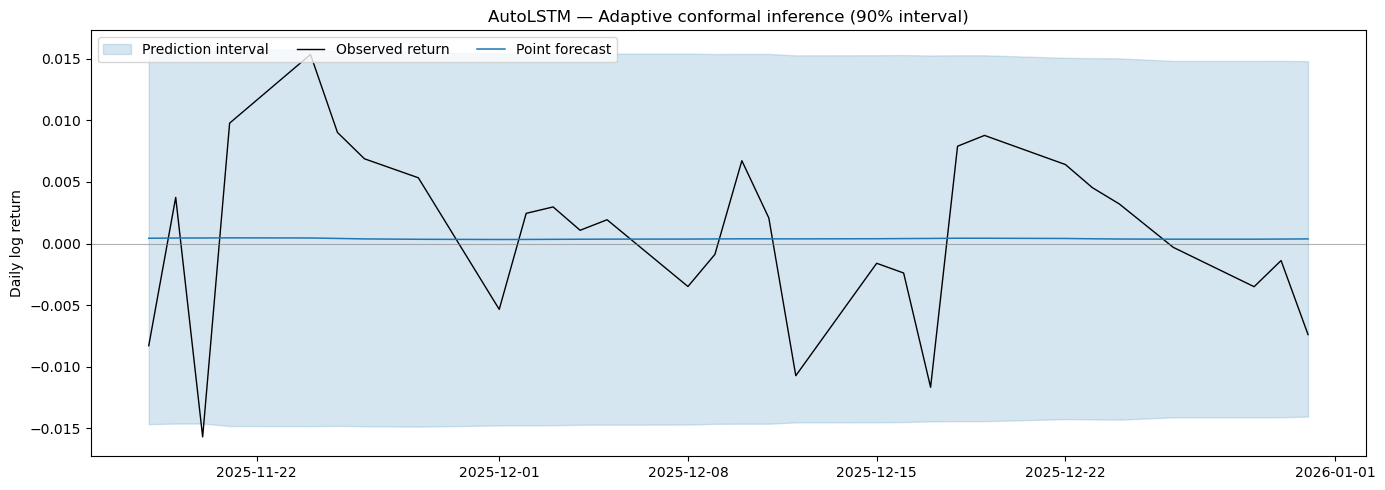

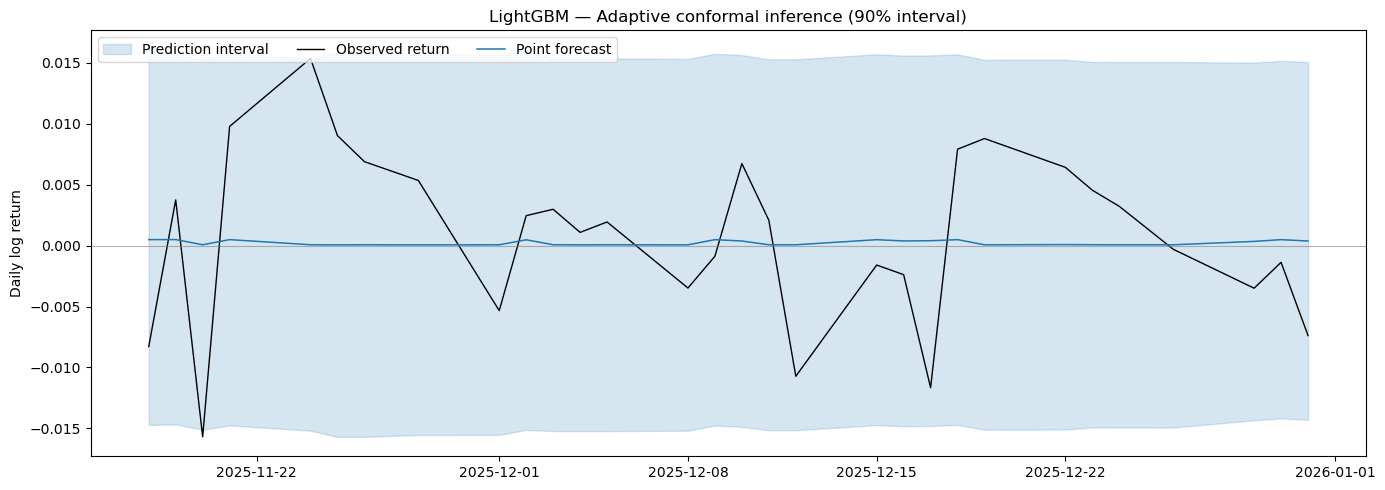

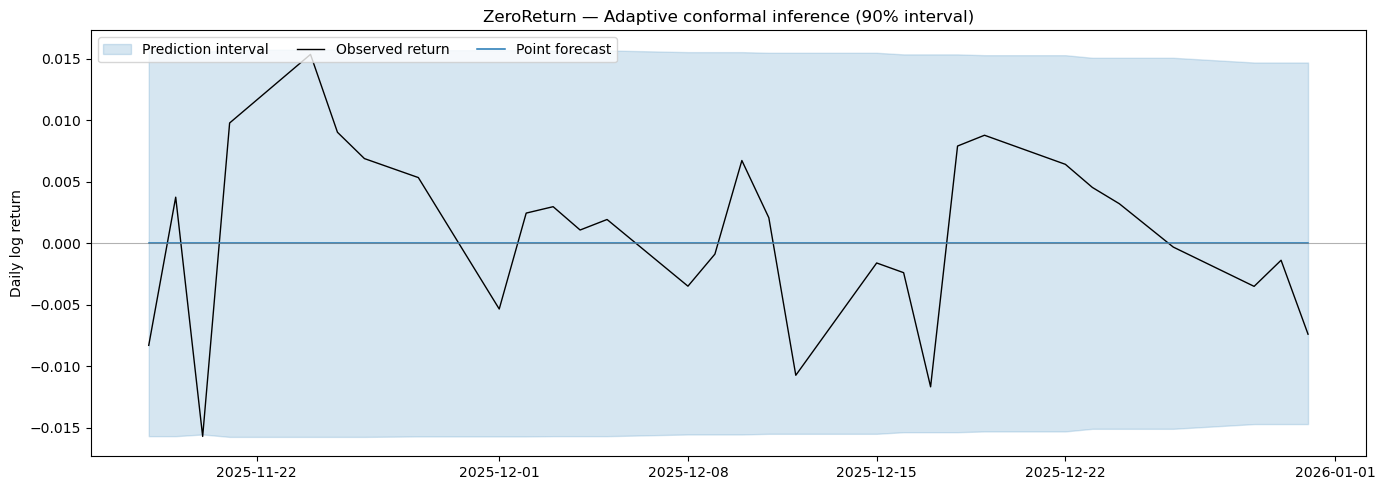

In [19]:
for model_label in interval_metrics['Model'].drop_duplicates():
    fig = plot_interval_forecast(
        interval_forecasts, model_label,
        method='Adaptive conformal inference', tail=PLOT_TAIL,
    )
    save_matplotlib_figure(
        fig,
        figure_path(
            'sp500_probabilistic_forecasting', 'sp500_returns', model_label, 'aci',
            extension=FIGURE_FORMAT,
        ),
        SAVE_FIGURES,
    )
    plt.show()
    plt.close(fig)

## Interpretation guardrails

- The model with the lowest 2025 error is **not** retrospectively declared the winner; selection was frozen using 2023 only.
- Coverage alone is insufficient. Compare empirical coverage, coverage error, mean interval width, and interval score together. The online fixed-alpha benchmark uses the same expanding score history as ACI while holding alpha at 0.10, isolating the effect of adaptive alpha.
- S&P 500 log returns are modeled directly. AutoStationary is not repeated because its diagnostic fit changed the already stationary target only by a negligible detrend.
- ACI is meaningful for one series: it needs a sequence of forecast errors, not a panel of many series.
- This exercise evaluates conditional interval adaptation, not market efficiency or a profitable trading rule.